# Data Cleaning and Exploratory Analysis

This notebook inspects the processed CCLE/DepMap expression matrix, TP53 labels, metadata, and EDA outputs.

In [10]:
from pathlib import Path
import os
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
pd.set_option("display.max_columns", 30)

## Load Processed Data

In [11]:
X = pd.read_csv("data/processed/expression_matched.csv.gz", index_col=0)
labels = pd.read_csv("data/processed/tp53_labels.csv")
metadata = pd.read_csv("data/processed/sample_metadata.csv")

X.shape, labels.shape, metadata.shape

((1719, 19215), (1719, 4), (1719, 49))

### Expression matrix (X)
Rows = cell lines, columns = genes. Values are log2(TPM + 1) RNA-seq expression.

In [12]:
# First 5 rows, first 8 genes
X.iloc[:5, :8]

,TSPAN6,TNMD,DPM1,SCYL3,FIRRM,FGR,CFH,FUCA2
ModelID,,,,,,,,
ACH-001113,4.956577,0.000000,7.577648,3.179411,4.765742,0.037483,1.510547,3.103039
ACH-001289,4.955015,0.617117,7.333933,2.782935,3.735371,0.000000,0.148922,3.855123
ACH-001339,3.421952,0.000000,7.546069,2.615880,4.476233,0.064571,1.397491,6.833915
ACH-001979,4.651643,0.000000,5.946408,2.454515,1.852111,0.000000,7.680796,6.156866
ACH-002438,4.336705,0.000000,6.879387,2.262824,3.256491,0.000000,2.253926,6.895436


In [13]:
# Summary stats for the first few genes
X.describe().iloc[:, :8]

,TSPAN6,TNMD,DPM1,SCYL3,FIRRM,FGR,CFH,FUCA2
count,1719.000000,1719.000000,1719.000000,1719.000000,1719.000000,1719.000000,1719.000000,1719.000000
mean,3.652079,0.090926,6.661592,2.562173,3.821440,0.426606,2.429958,5.232586
std,1.739152,0.485808,0.672585,0.566300,0.848169,1.208609,2.429306,1.856853
min,0.000000,0.000000,3.296603,0.855869,0.442235,0.000000,0.000000,0.000000
25%,3.189104,0.000000,6.228043,2.193314,3.335184,0.010029,0.154927,4.789635
50%,4.125940,0.000000,6.643289,2.545193,3.925724,0.041407,1.577881,5.779354
75%,4.799064,0.000000,7.084128,2.896913,4.395344,0.142964,4.420519,6.418154
max,8.371990,9.753808,9.594667,4.830042,6.100198,7.962283,9.820420,8.838646


### Labels
One row per cell line. `tp53_mutant` = 1 if any TP53 mutation, 0 if wild-type.

In [14]:
labels.head(10)

,sample_id,tp53_mutant,mutation_type,mutation_type_collapsed
0,ACH-001113,1,Missense,Missense
1,ACH-001289,0,WT,WT
2,ACH-001339,1,Missense,Missense
3,ACH-001979,0,WT,WT
4,ACH-002438,0,WT,WT
5,ACH-001538,0,WT,WT
6,ACH-000242,0,WT,WT
7,ACH-000708,0,WT,WT
8,ACH-000327,0,WT,WT
9,ACH-000233,1,Missense,Missense


### Metadata
Cell line annotations: cancer type, tissue of origin, etc.

In [26]:
key_cols = ["sample_id", "CellLineName", "OncotreeLineage", "OncotreePrimaryDisease", "Age", "Sex"]
metadata[[c for c in key_cols if c in metadata.columns]].head(10)

,sample_id,CellLineName,OncotreeLineage,OncotreePrimaryDisease,Age,Sex
0,ACH-001113,LC-1/sq-SF,Lung,Non-Small Cell Lung Cancer,69.0,Male
1,ACH-001289,COG-AR-359,CNS/Brain,Embryonal Tumor,NaN,Male
2,ACH-001339,Colo 794,Skin,Melanoma,14.0,Male
3,ACH-001979,NZM11,Skin,Melanoma,41.0,Male
4,ACH-002438,CCLF_PEDS_0026_T,Kidney,Wilms' Tumor,4.0,Male
5,ACH-001538,KKU-213,Biliary Tract,Intraductal Papillary Neoplasm of the Bile Duct,58.0,Male
6,ACH-000242,RT4,Bladder/Urinary Tract,Bladder Urothelial Carcinoma,63.0,Male
7,ACH-000708,SNU-283,Bowel,Colorectal Adenocarcinoma,62.0,Female
8,ACH-000327,NCI-H1395,Lung,Non-Small Cell Lung Cancer,55.0,Female
9,ACH-000233,DEL,Lymphoid,Mature T and NK Neoplasms,12.0,Male


In [27]:
labels.head()

,sample_id,tp53_mutant,mutation_type,mutation_type_collapsed
0,ACH-001113,1,Missense,Missense
1,ACH-001289,0,WT,WT
2,ACH-001339,1,Missense,Missense
3,ACH-001979,0,WT,WT
4,ACH-002438,0,WT,WT


In [28]:
metadata[[col for col in ["sample_id", "CellLineName", "OncotreeLineage", "OncotreePrimaryDisease"] if col in metadata.columns]].head()

,sample_id,CellLineName,OncotreeLineage,OncotreePrimaryDisease
0,ACH-001113,LC-1/sq-SF,Lung,Non-Small Cell Lung Cancer
1,ACH-001289,COG-AR-359,CNS/Brain,Embryonal Tumor
2,ACH-001339,Colo 794,Skin,Melanoma
3,ACH-001979,NZM11,Skin,Melanoma
4,ACH-002438,CCLF_PEDS_0026_T,Kidney,Wilms' Tumor


## Class Balance

In [29]:
pd.read_csv("reports/tables/binary_class_balance.csv")

,class,count,percentage
0,Mutant,997,57.998837
1,WT,722,42.001163


In [19]:
pd.read_csv("reports/tables/mutation_type_balance.csv")

,mutation_type,count,percentage
0,WT,722,42.001163
1,Missense,620,36.067481
2,Other,189,10.994764
3,Nonsense,113,6.573589
4,Frameshift,58,3.374055
5,In-frame indel,9,0.523560
6,Synonymous,8,0.465387


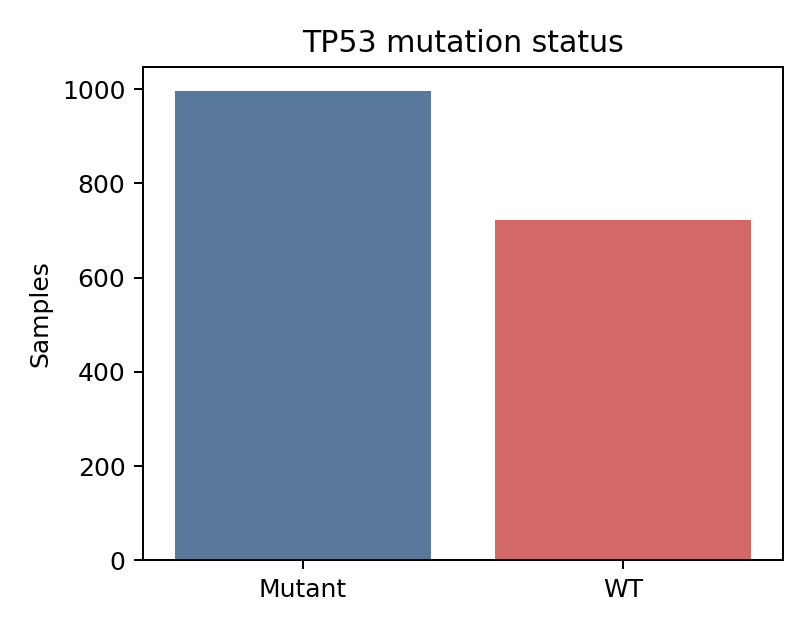

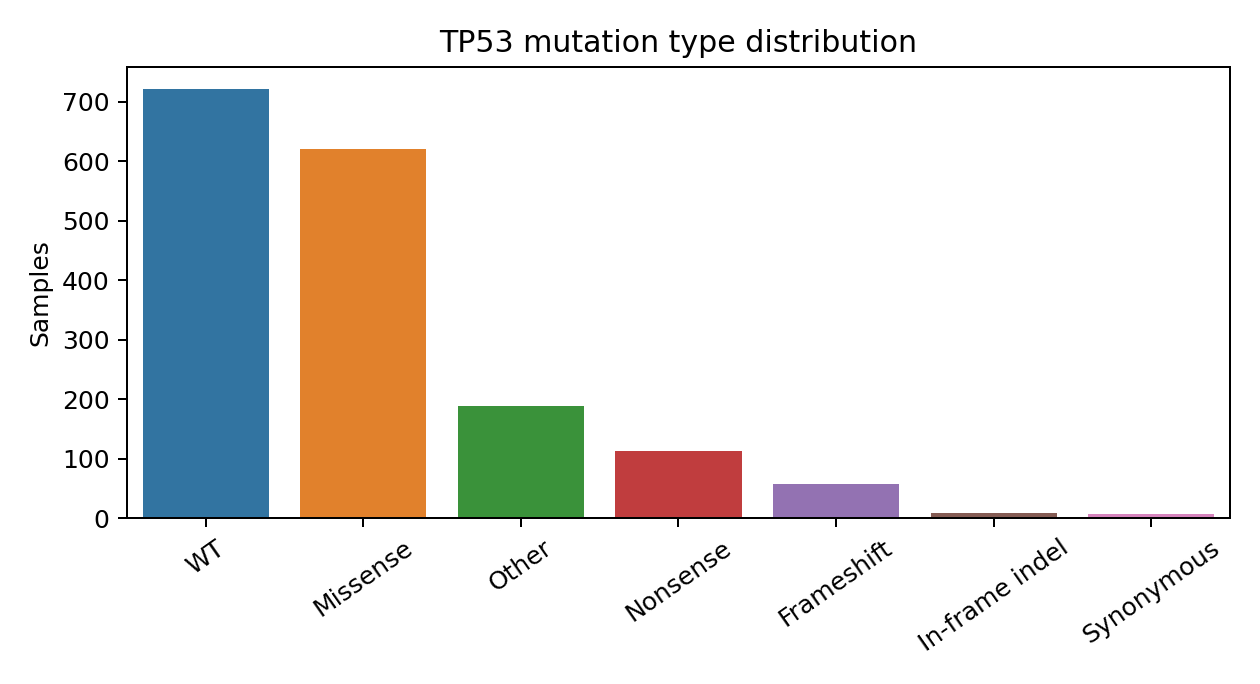

In [20]:
display(Image(filename="reports/figures/binary_class_balance.png"))
display(Image(filename="reports/figures/mutation_type_balance.png"))

## Expression Summary and PCA

In [21]:
pd.read_csv("reports/tables/expression_summary.csv")

,metric,value
0,samples,1719.000000
1,genes,19215.000000
2,missing_values,0.000000
3,mean_expression,2.670069
4,median_expression,2.415231


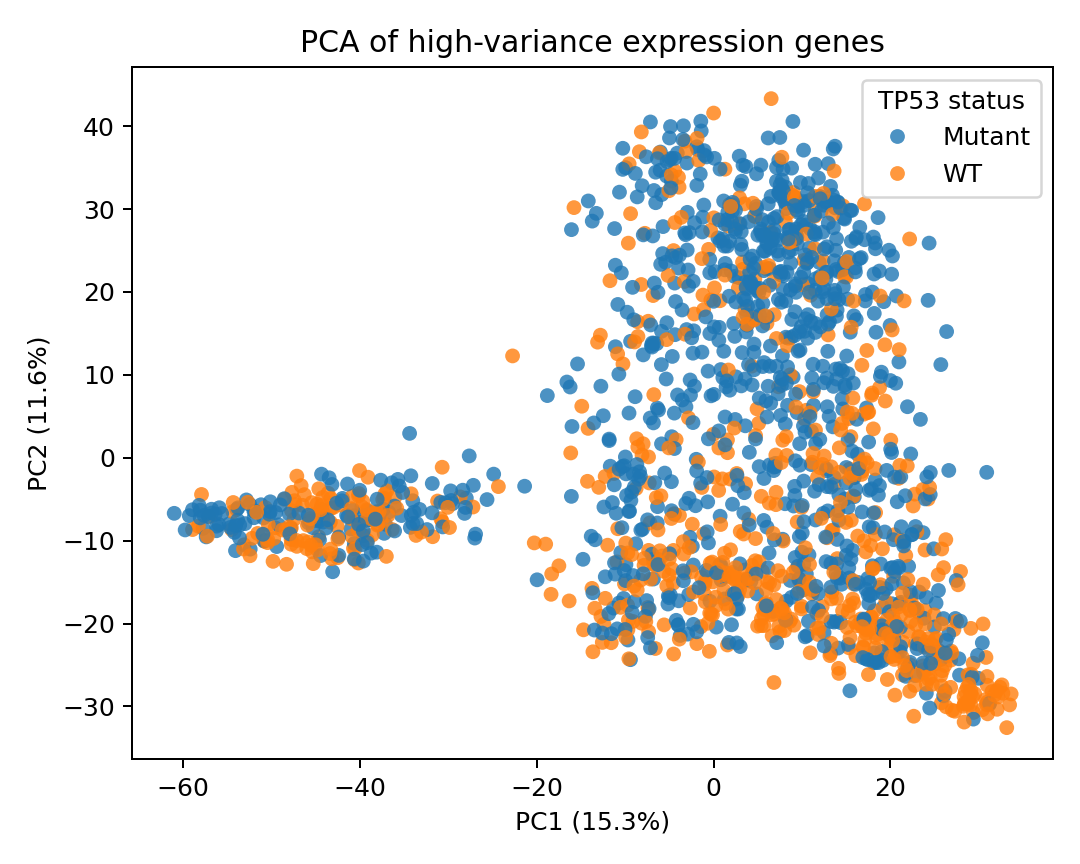

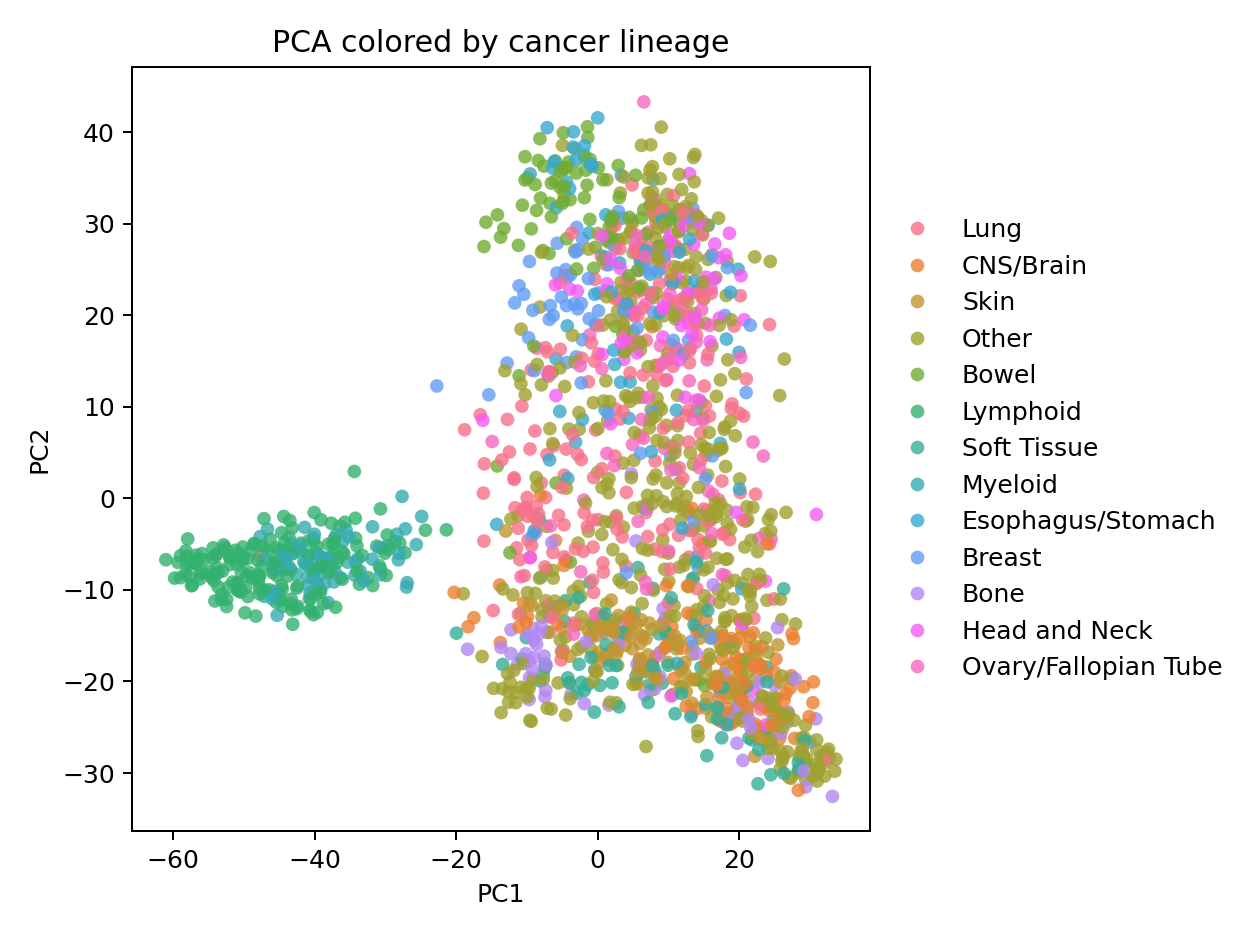

In [22]:
display(Image(filename="reports/figures/pca_tp53_status.png"))
display(Image(filename="reports/figures/pca_lineage.png"))